In [2]:
from pathlib import Path
from nucleo.io.plots_2D import plot_all_heatmaps

root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19/")

plot_all_heatmaps(
    speed_cols=["vf", "wf"],
    root=root,
    type_of_data="norm_th",
    plot_log2=True,
)

Plotting heatmaps: 100%|██████████| 20/20 [00:02<00:00,  9.40it/s]


(<Figure size 7200x32000 with 80 Axes>,
 array([[<Axes: title={'center': "{'s': 150, 'l': 5, 'bpmin': 0, 'land': 'periodic'}"}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>,
         <Axes: title={'center': "{'s': 150, 'l': 5, 'bpmin': 0, 'land': 'periodic'}"}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>],
        [<Axes: title={'center': "{'s': 150, 'l': 10, 'bpmin': 0, 'land': 'periodic'}"}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>,
         <Axes: title={'center': "{'s': 150, 'l': 10, 'bpmin': 0, 'land': 'periodic'}"}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>],
        [<Axes: title={'center': "{'s': 150, 'l': 15, 'bpmin': 0, 'land': 'periodic'}"}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>,
         <Axes: title={'center': "{'s': 150, 'l': 15, 'bpmin': 0, 'land': 'periodic'}"}, xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>],
        [<Axes: title={'center': "{'s': 150, 'l': 20, 'bpmin': 0, 'land': 'periodic'}"}, 

Scanning 222200 parquet files...


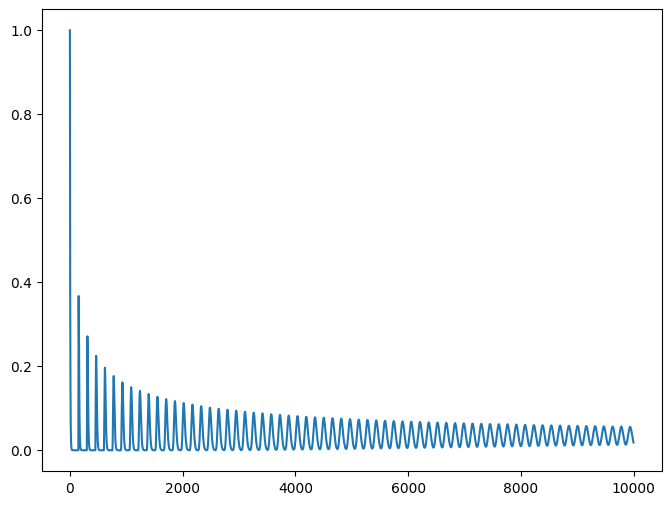

In [15]:
from nucleo.io.reading import finding_one_parquet
import numpy as np
import matplotlib.pyplot as plt

root = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19"

params_fixed = {
    "algo": "1S", 
    "fact": False, 
    "mode": "none", 
    "dstr": False,
    "s": 150,
    "mu": 150, 
    "theta": 100, 
    "alphar": 0.00, 
    "Kp": 0.00, 
    "Kz": 0.00
}

params_random_l5 = {
    **params_fixed,
    "land": "random",
    "l": 5,
    "bpmin": 0
}

df_random_l5 = finding_one_parquet(
    root=root,
    params=params_random_l5
)

l_view_to_plot = df_random_l5["l_view"][0].to_numpy()
plt.figure(figsize=(8,6))
plt.plot(l_view_to_plot)
plt.show()

In [ ]:
import polars as pl

root_config = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19/scenarios.json"
df_config = pl.read_json(root_config)

fig, axes = plt.subplots(ncols=1, nrows=df_config.height)
for (ax, row) in zip (axes, df_config.iter_rows()):

    land = row[3]
    l = row[1]
    bpmin = row[2]

    params_row = {
        **params_fixed,
        "land": land,
        "l": l,
        "bpmin": bpmin
    }

    df_plot = finding_one_parquet(
        root=root,
        params=params_row
    )

    l_view_to_plot = df_plot["l_view"][0].to_numpy()
    ax.set_title(f"land={land} - l={l} - bpmin={bpmin}")
    ax.plot(l_view_to_plot)
    ax.set_xlabel("Position")
    ax.set_ylabel("Distribution")
    ax.grid(True, which="both", alpha=0.30)

plt.show()

Scanning 222200 parquet files...
Scanning 222200 parquet files...
Scanning 222200 parquet files...
Scanning 222200 parquet files...
Scanning 222200 parquet files...
Scanning 222200 parquet files...
Scanning 222200 parquet files...
Scanning 222200 parquet files...


# .